# 1D-CNN 기반 네트워크 침입 탐지 (다중 분류)

**모델**: 1D-CNN (PyTorch)  
**분류 클래스**: Benign / Bot / Brute Force / DDoS / DoS / Infiltration / SQL Injection

---
### 순서
1. 라이브러리 임포트  
2. 데이터 로드 & 분할  
3. Dataset / DataLoader 정의  
4. 1D-CNN 모델 정의  
5. 학습  
6. 평가 (Confusion Matrix, Classification Report)  
7. 모델 저장

## 1. 라이브러리 임포트

In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 재현성 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

PyTorch version : 2.10.0+cpu
Device          : cpu


## 2. 데이터 로드 & 분할

In [2]:
BASE_DIR    = os.path.dirname(os.path.abspath("__file__"))
OUTPUT_DIR  = os.path.join(BASE_DIR, "processed")
MODEL_DIR   = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X = np.load(os.path.join(OUTPUT_DIR, "X.npy"))
y = np.load(os.path.join(OUTPUT_DIR, "y.npy"))

with open(os.path.join(OUTPUT_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = json.load(f)

# {숫자: 이름} 형태로 변환
idx2label = {v: k for k, v in label_mapping.items()}
class_names = [idx2label[i] for i in range(len(idx2label))]
num_classes = len(class_names)

print(f"X shape      : {X.shape}")
print(f"y shape      : {y.shape}")
print(f"클래스 수    : {num_classes}")
print(f"클래스 목록  : {class_names}")

X shape      : (2330915, 70)
y shape      : (2330915,)
클래스 수    : 7
클래스 목록  : ['Benign', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Infiltration', 'SQL Injection']


In [3]:
# Train 70 / Val 15 / Test 15 분할
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train : {X_train.shape[0]:,}")
print(f"Val   : {X_val.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

Train : 1,631,640
Val   : 349,637
Test  : 349,638


## 3. Dataset / DataLoader 정의

In [4]:
class IDSDataset(Dataset):
    """
    1D-CNN 입력 형태: (batch, 1, num_features)
    피처 벡터를 채널=1의 1D 시퀀스로 취급
    """
    def __init__(self, X, y):
        # (N, F) → (N, 1, F)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512

train_loader = DataLoader(IDSDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(IDSDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(IDSDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 3187
Val   batches : 683
Test  batches : 683


## 4. 1D-CNN 모델 정의

```
입력: (B, 1, F)
 ↓ Conv Block 1 : Conv1d(1→64,  k=3) → BN → ReLU → MaxPool(2)
 ↓ Conv Block 2 : Conv1d(64→128, k=3) → BN → ReLU → MaxPool(2)
 ↓ Conv Block 3 : Conv1d(128→256, k=3) → BN → ReLU → AdaptiveAvgPool(1)
 ↓ Flatten
 ↓ FC(256→128) → ReLU → Dropout(0.3)
 ↓ FC(128→num_classes)
```

In [5]:
class CNN1D(nn.Module):
    def __init__(self, num_features: int, num_classes: int, dropout: float = 0.3):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 2
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 3
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # 피처 수에 관계없이 (B, 256, 1) 로 고정
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv_blocks(x)
        return self.classifier(x)


num_features = X_train.shape[1]
model = CNN1D(num_features=num_features, num_classes=num_classes).to(DEVICE)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\n학습 가능 파라미터 수: {total_params:,}")

CNN1D(
  (conv_blocks): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, ou

## 5. 학습

In [6]:
EPOCHS   = 30
LR       = 1e-3
PATIENCE = 5

CKPT_PATH = os.path.join(MODEL_DIR, "checkpoint.pt")  # 매 epoch 저장
BEST_PATH = os.path.join(MODEL_DIR, "best_model.pt")  # best val_loss 저장

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
patience_cnt  = 0
start_epoch   = 1

# 체크포인트 복원
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    history       = ckpt["history"]
    best_val_loss = ckpt["best_val_loss"]
    patience_cnt  = ckpt["patience_cnt"]
    start_epoch   = ckpt["epoch"] + 1
    print(f"체크포인트 복원 완료 → epoch {ckpt['epoch']} 이후부터 재시작")
else:
    print("체크포인트 없음 → 처음부터 학습")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


for epoch in range(start_epoch, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}")

    # Best 모델 저장
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_cnt  = 0
        torch.save(model.state_dict(), BEST_PATH)
    else:
        patience_cnt += 1

    # 매 epoch 체크포인트 저장
    torch.save({
        "epoch"           : epoch,
        "model_state"     : model.state_dict(),
        "optimizer_state" : optimizer.state_dict(),
        "scheduler_state" : scheduler.state_dict(),
        "history"         : history,
        "best_val_loss"   : best_val_loss,
        "patience_cnt"    : patience_cnt,
    }, CKPT_PATH)

    if patience_cnt >= PATIENCE:
        print(f"\nEarly Stopping (patience={PATIENCE})")
        break

print("\n학습 완료. Best val_loss:", round(best_val_loss, 4))

체크포인트 없음 → 처음부터 학습
Epoch 01/30  train_loss=0.2319  train_acc=0.8991  val_loss=0.2185  val_acc=0.9067
Epoch 02/30  train_loss=0.2011  train_acc=0.9078  val_loss=0.2061  val_acc=0.9081
Epoch 03/30  train_loss=0.1975  train_acc=0.9088  val_loss=0.2009  val_acc=0.9101
Epoch 04/30  train_loss=0.1957  train_acc=0.9094  val_loss=0.2026  val_acc=0.9049
Epoch 05/30  train_loss=0.1937  train_acc=0.9100  val_loss=0.1943  val_acc=0.9108
Epoch 06/30  train_loss=0.1939  train_acc=0.9101  val_loss=0.2095  val_acc=0.9073
Epoch 07/30  train_loss=0.1921  train_acc=0.9107  val_loss=0.2013  val_acc=0.9056
Epoch 08/30  train_loss=0.1905  train_acc=0.9113  val_loss=0.2020  val_acc=0.9076
Epoch 09/30  train_loss=0.1900  train_acc=0.9116  val_loss=0.1943  val_acc=0.9101
Epoch 10/30  train_loss=0.1872  train_acc=0.9123  val_loss=0.1905  val_acc=0.9097
Epoch 11/30  train_loss=0.1866  train_acc=0.9125  val_loss=0.1913  val_acc=0.9107
Epoch 12/30  train_loss=0.1862  train_acc=0.9125  val_loss=0.1871  val_acc=0.91

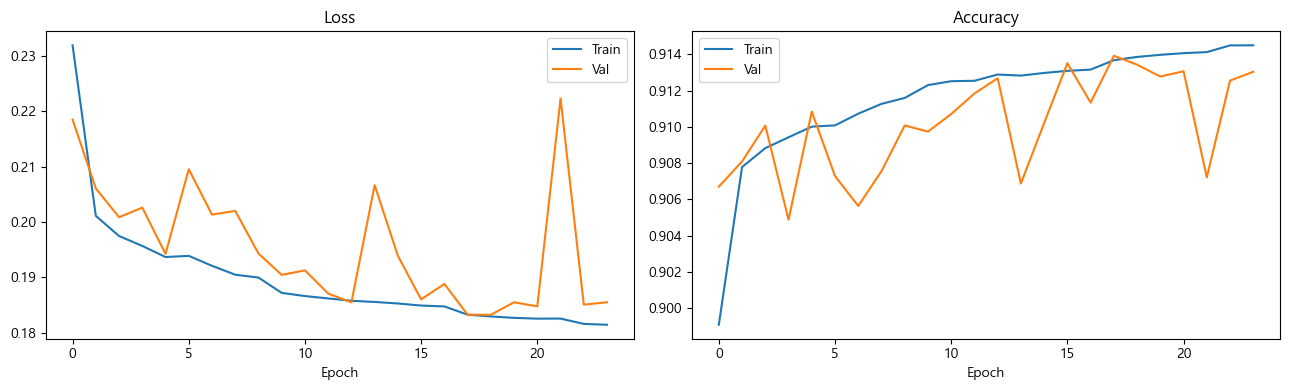

In [7]:
# Loss / Accuracy 커브
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. 평가

In [8]:
# Best 모델 로드 후 Test 평가
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best_model.pt"), map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

=== Classification Report ===
               precision    recall  f1-score   support

       Benign     0.8048    0.9845    0.8856     75000
          Bot     0.9997    0.9999    0.9998     42929
  Brute Force     0.8667    0.9472    0.9052     57269
         DDoS     0.9978    1.0000    0.9989     75000
          DoS     0.9571    0.8888    0.9217     75000
 Infiltration     0.8675    0.2631    0.4037     24290
SQL Injection     0.7737    0.9800    0.8647       150

     accuracy                         0.9129    349638
    macro avg     0.8953    0.8662    0.8542    349638
 weighted avg     0.9173    0.9129    0.9014    349638



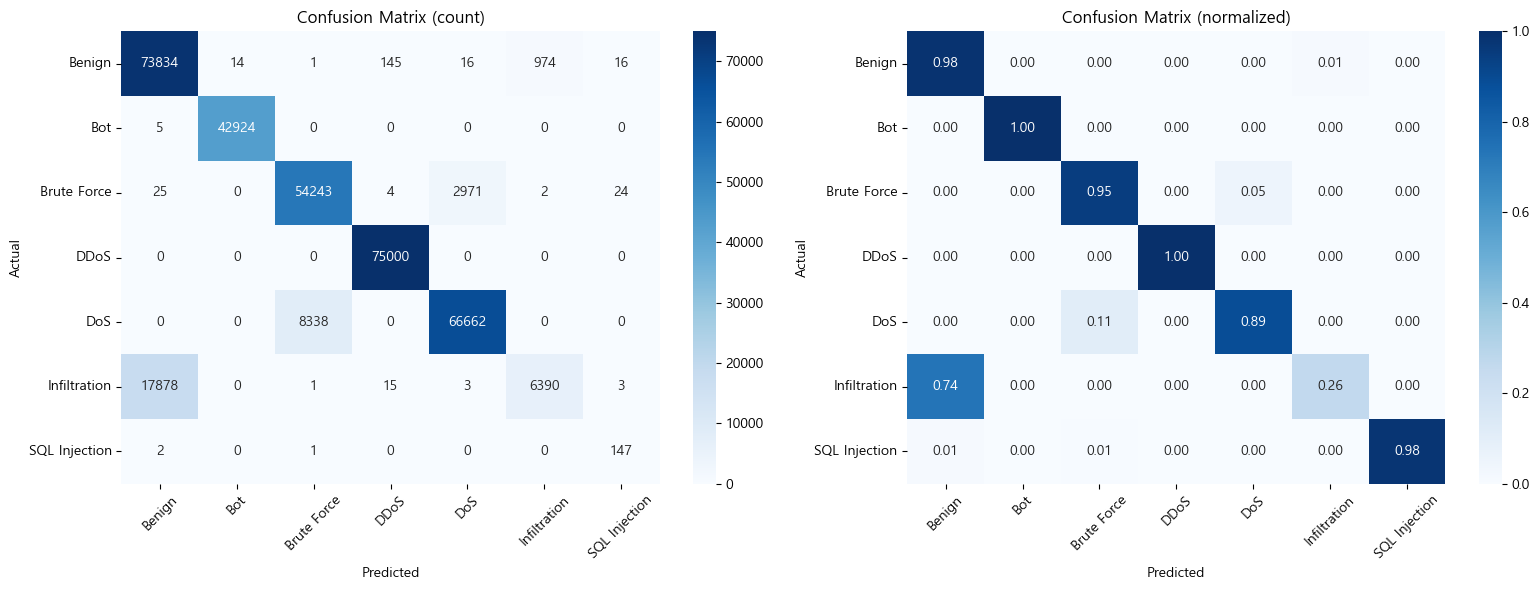

In [9]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (count)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. 모델 저장

In [10]:
import json

# 모델 구조 + 하이퍼파라미터 메타데이터 저장
meta = {
    "num_features" : num_features,
    "num_classes"  : num_classes,
    "class_names"  : class_names,
    "label_mapping": label_mapping,
    "batch_size"   : BATCH_SIZE,
    "epochs_trained": len(history["train_loss"]),
    "best_val_loss": round(best_val_loss, 6),
}
with open(os.path.join(MODEL_DIR, "model_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("저장 완료!")
print(f"  models/best_model.pt   — 학습된 가중치")
print(f"  models/model_meta.json — 모델 메타데이터")

저장 완료!
  models/best_model.pt   — 학습된 가중치
  models/model_meta.json — 모델 메타데이터
